# XGB classifier
- binary classification, using all features
- Final model uses data without imputation
- Also we use only adult patients

In [191]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from matplotlib import pyplot
import xgboost as xgb
from imblearn.over_sampling import RandomOverSampler
import matplotlib.patches as mpatches

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    accuracy_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    cohen_kappa_score
)

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV, StratifiedGroupKFold

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

pd.set_option('display.max_columns', None)



Initialize metrics dataframe

In [192]:
metrics_df = pd.DataFrame(columns=['data', 'F1_score', 'kappa', 'recall', 'precision', 'accuracy', 'customf1', 'specificity', 'PNV'])

### Functions

In [193]:
def proba_to_labels(p, threshold: float):
    """Convert probabilities to 0/1 labels."""
    return (p >= threshold).astype(int)

In [194]:

def plot_cv_mean_confusion_matrix_rowpct(
    mean_mat, std_mat=None,
    *,
    mean_cnt=None, std_cnt=None,     # <-- NEW (optional raw counts)
    title="CV mean (± std) confusion matrix (row %)",
    threshold=None,
    save_path=None,
    cmap="viridis",
    text_color=None,
    figsize=(6, 5),
    alpha=1.0,
):
    """
    Plot a single 2x2 macro-averaged confusion matrix where `mean_mat` and `std_mat`
    are row-normalized FRACTIONS (0..1). This renders as percentages.

    Optionally, also display raw-count mean (`mean_cnt`) and std (`std_cnt`) per cell.
    Shapes expected: (2, 2) for all matrices.
    """
    mean_mat = np.asarray(mean_mat, float)
    std_mat  = None if std_mat is None else np.asarray(std_mat, float)

    # Percent view for heatmap
    perc = mean_mat * 100.0
    stdp = None if std_mat is None else (std_mat * 100.0)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(perc, cmap=cmap, alpha=alpha, vmin=0, vmax=100)

    # ---- Annotations in each cell ----
    for i in range(perc.shape[0]):
        for j in range(perc.shape[1]):
            # First line: percent ± std%
            if stdp is None:
                line1 = f"{perc[i, j]:.1f}%"
            else:
                line1 = f"{perc[i, j]:.1f}% ± {stdp[i, j]:.1f}"

            # Second line: count ± std (if provided)
            line2 = None
            if mean_cnt is not None:
                mcnt = float(mean_cnt[i, j])
                if std_cnt is not None:
                    scnt = float(std_cnt[i, j])
                    line2 = f"{mcnt:.1f} ± {scnt:.1f}"
                else:
                    line2 = f"{mcnt:.1f}"

            txt = line1 if line2 is None else f"{line1}\n{line2}"

            # text color: auto-contrast unless overridden
            color = "black" if (text_color is None and perc[i, j] <= perc.max()/2) else \
                    ("white" if text_color is None else text_color)

            ax.text(j, i, txt, ha="center", va="center", fontsize=13, color=color)

    # Axes labels/ticks
    ax.set(
        xticks=np.arange(2), yticks=np.arange(2),
        xticklabels=[0, 1], yticklabels=[0, 1],
        xlabel="Predicted label", ylabel="True label",
    )

    full_title = title
    if threshold is not None:
        full_title += f"\nthreshold={threshold:.3f}"
    ax.set_title(full_title, fontsize=14)

    # Colorbar in % scale
    cbar = plt.colorbar(im)
    cbar.set_label("% (row-normalized)", rotation=90)
    cbar.ax.tick_params(labelsize=12)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        # plt.close(fig)
    # else: plt.show()  # up to you


In [195]:
def calc_pnv(y_true, y_pred):
    """
    Compute PNV (Negative Predictive Value) for binary data.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Predicted negative = 0
    TN = np.sum((y_pred == 0) & (y_true == 0))  # true negatives
    FN = np.sum((y_pred == 0) & (y_true == 1))  # false negatives

    if TN + FN == 0:
        return np.nan  # no predicted negatives → PNV undefined

    return TN / (TN + FN)

In [196]:
def plot_confusion_matrix_with_percentages(
    y_true,
    y_pred,
    labels=None,
    percent_type="row",   # 'row', 'column', or 'all'
    title=None,
    cmap="viridis",
    threshold=None,
    save_path=None,
    figsize=None,
    text_color=None
):
    '''
    Function for matrix display
    '''
    from sklearn.metrics import confusion_matrix
    import numpy as np
    import matplotlib.pyplot as plt

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    if labels is None:
        labels = np.unique(y_true)

    # Calculate percentages
    if percent_type == "row":
        sums = cm.sum(axis=1, keepdims=True)
        perc = cm / np.where(sums == 0, 1, sums) * 100
        perc_label = "Row %"
    elif percent_type == "column":
        sums = cm.sum(axis=0, keepdims=True)
        perc = cm / np.where(sums == 0, 1, sums) * 100
        perc_label = "Col %"
    elif percent_type == "all":
        total = cm.sum()
        perc = (cm / total * 100) if total != 0 else np.zeros_like(cm, dtype=float)
        perc_label = "All %"
    else:
        raise ValueError("percent_type must be 'row', 'column', or 'all'")

    # Annotation with count and percentage
    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n({perc[i, j]:.0f}%)"

    fig, ax = plt.subplots(figsize=figsize)

    # Heatmap uses PERCENTAGES so colors + colorbar are %
    im = ax.imshow(perc, cmap=cmap, vmin=0, vmax=100)
    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.tick_params(labelsize=12)
    cbar.set_label("Percent (%)", fontsize=12)

    # Show numbers
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if text_color is None:
                # background is % (0..100), so use 50 as midpoint
                cell_color = "black" if perc[i, j] > 50 else "white"
            else:
                cell_color = text_color

            ax.text(
                j, i, annot[i, j],
                ha="center", va="center",
                fontsize=13,
                color=cell_color
            )

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        xlabel="Predicted label",
        ylabel="True label",
    )

    ax.set_xlabel("Predicted label", fontsize=14)
    ax.set_ylabel("True label", fontsize=14)
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)

    full_title = title if title else f"Confusion Matrix with {perc_label}"
    # if threshold is not None:
    #     full_title += f"\nthreshold={threshold}"
    ax.set_title(full_title, fontsize=14)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


In [197]:
def custom_score(y_true, y_pred, group_ids, threshold, eval=False):
    '''
    Custom score function to correct early detections to correct
    '''
    # Binary prediction
    y_bin = (y_pred >= threshold).astype(int)
    print(f"f1 before mod: {f1_score(y_true, y_bin)}")
    # Create working DataFrame
    df = pd.DataFrame({
        'henkilotunnus': group_ids,
        'true_label': y_true,
        'predicted_label': y_bin
    })

    df['misclassified'] = (df['true_label'] != df['predicted_label']).astype(int)
    df['misclassified_proximity'] = 0

    # Set proximity rule
    for name, group in df.groupby('henkilotunnus'):
        for i in range(len(group) - 1):
            row = group.iloc[i]
            next_row = group.iloc[i + 1]

            if (
                row['misclassified'] == 1
                and row['true_label'] == 0
                and row['predicted_label'] == 1
                and next_row['true_label'] == 1
            ):
                df.loc[group.index[i], 'misclassified_proximity'] = 1
 
    # Adjust predictions
    adjusted_pred = df['predicted_label'].copy()
    mask = (df['misclassified'] == 1) & (df['misclassified_proximity'] == 1)
    adjusted_pred[mask] = df['true_label'][mask]

    if eval:
        return df, f1_score(df['true_label'], adjusted_pred), adjusted_pred
    else:
        return f1_score(df['true_label'], adjusted_pred)

In [198]:
def move_column_inplace(df, col, pos):
    col = df.pop(col)
    df.insert(pos, col.name, col)

## Data

In [199]:
SEED = 43
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)

In [200]:
# different data imputation potions
dfnames = ['interpolation', 'uncertainty', 'NOimputation']
i = 2
DATA_SOURCE = dfnames[i]
PLOT_PATH = f'/path/to/plots/train2_test2/{DATA_SOURCE}/'
DATA_PATH = f"/path/to/data/train2_test2/{DATA_SOURCE}/"
print("Data source:", DATA_SOURCE)

Data source: NOimputation


In [201]:
# load data
df = pd.read_csv(f"/path/to/data/model_data_{DATA_SOURCE}.csv").drop(columns='Unnamed: 0')
rmv_list = df.loc[df['fn_day']==1].index # remove day when febrile neutropenia occurs
df = df.drop(rmv_list)

X = df.drop(columns=['henkilotunnus', 'infektion_binary', 'treatment_date', 'naytteenotto_hetki', 'fn_day'])
y = df['infektion_binary']
group = df['henkilotunnus']


In [202]:
# save featurenames as list for later usage
pd.DataFrame(X.columns.to_numpy(), columns=['Feature']).to_csv(DATA_PATH + "X_features_as_list.csv")

### Statistics from dataset

In [203]:
print('Number of patients:', len(df['henkilotunnus'].drop_duplicates()))
print('Number of treatment cycles:', len(df.groupby(['henkilotunnus', 'cycle_number']).size()))
print('Number of datapoints:', len(df))
print()
print('Number of features:', len(X.columns))
print("Number of Inductions (row %):", round(len(X[X['sykli_IND']==1])/len(X), 3))
print("Number of Consolidations (row %):", round(len(X[X['sykli_IND']==0])/len(X), 3))
print("Number of treatment cycles:", len(df.groupby(['henkilotunnus', 'cycle_number']).size()))
print()
print("Number of Induction cycles:", len(df[df['sykli_IND']==1].groupby(['henkilotunnus', 'cycle_number']).size()))
print("Number of Consolidation cycles:", len(df[df['sykli_IND']==0].groupby(['henkilotunnus', 'cycle_number']).size()))
print()
print("Number of infection cycles in Inductions:", df[df['sykli_IND']==1].groupby(['henkilotunnus', 'cycle_number'])['infektion_binary'].any().sum())
print("Number of infection cycles in Consolidations:", df[df['sykli_IND']==0].groupby(['henkilotunnus', 'cycle_number'])['infektion_binary'].any().sum())
print('Number of FN:', len(df[df['infektion_binary']==1]))
print('Number of non-FN:', len(df[df['infektion_binary']==0]))
print()
years = pd.DatetimeIndex(df['naytteenotto_hetki']).year.drop_duplicates().sort_values()
print(f"Data collected between years {years.min()}-{years.max()}")

Number of patients: 271
Number of treatment cycles: 646
Number of datapoints: 5532

Number of features: 272
Number of Inductions (row %): 0.315
Number of Consolidations (row %): 0.685
Number of treatment cycles: 646

Number of Induction cycles: 206
Number of Consolidation cycles: 440

Number of infection cycles in Inductions: 182
Number of infection cycles in Consolidations: 158
Number of FN: 540
Number of non-FN: 4992

Data collected between years 2012-2025


### Split the data to train / test / validation
- Group wise 
- test 20% and train 80%

In [204]:
# Group depending test / train split
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
for train_idx, test_idx in splitter.split(X, y, groups=group):
    X_tr, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_test = y.iloc[train_idx], y.iloc[test_idx]
    group_tr, group_test = group.iloc[train_idx], group.iloc[test_idx]
    df_tr, df_test = df.iloc[train_idx], df.iloc[test_idx]


Remove not needed lab value columns

In [205]:
dfs = [X_test, X_tr, df_test]

drop_nuisances = False
if drop_nuisances:
    for i, df in enumerate(dfs):
        cols_to_drop = [
            c for c in df.columns
            if c.startswith("s_") or (c.startswith("p_") and not c.startswith("p_crp"))
        ]
        df.drop(columns=cols_to_drop, inplace=True)


In [206]:
print('Number of features:', len(X_tr.columns))

Number of features: 272


In [207]:
# save test train splits for later use
X_tr.to_csv(DATA_PATH + "X_train.csv")
y_tr.to_csv(DATA_PATH + "y_train.csv")
X_test.to_csv(DATA_PATH + "X_test.csv")
y_test.to_csv(DATA_PATH + "y_test.csv")
group_tr.to_csv(DATA_PATH + "group_train.csv")
group_test.to_csv(DATA_PATH + "group_test.csv")
df_test.to_csv(DATA_PATH + "df_test.csv")
df_tr.to_csv(DATA_PATH + 'df_tr.csv')

In [208]:
# more statistics after split
nofones = y.tolist().count(1)/y.tolist().count(0)
print(f"Portion of 1 in dataset: {nofones:.3f}")
print()
print('Number of induction datapoints:', len(X[X['sykli_IND']==1]))
print('Number of consolidation datapoints:', len(X[X['sykli_IND']==0]))
print()
print('Number of pateints in train set', len(df_tr['henkilotunnus'].drop_duplicates()))
print('Number of pateints in test set', len(df_test['henkilotunnus'].drop_duplicates()))
print()
print('Number of treatment cycles in train set:', len(df_tr.groupby(['henkilotunnus', 'cycle_number']).size()))
print('Number of treatment cycles in test set:', len(df_test.groupby(['henkilotunnus', 'cycle_number']).size()))
print()
print('Number of datapoints in train set:', len(df_tr))
print('Number of datapoints in test set:', len(df_test))
print()
print("Number of FN in training set", int(y_tr.reset_index()['infektion_binary'].sum()))
print("Number of FN in testing set", int(y_test.reset_index()['infektion_binary'].sum()))

Portion of 1 in dataset: 0.108

Number of induction datapoints: 1740
Number of consolidation datapoints: 3792

Number of pateints in train set 216
Number of pateints in test set 55

Number of treatment cycles in train set: 508
Number of treatment cycles in test set: 138

Number of datapoints in train set: 4447
Number of datapoints in test set: 1085

Number of FN in training set 431
Number of FN in testing set 109


## Grid search hyperparameter tuning

In [209]:
# 2) Imbalance scale from TRAIN
neg_cnt = y_tr.value_counts()[0]
pos_cnt = y_tr.value_counts()[1]
scale1 = (neg_cnt / pos_cnt) ** 0.5
scale2 = (neg_cnt / pos_cnt)

In [210]:
GS = False
if GS:    

    # 1) Train/val split with groups (your style)
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    for train_idx, val_idx in splitter.split(X_tr, y_tr, groups=group_tr):
        X_train, X_val = X_tr.iloc[train_idx], X_tr.iloc[val_idx]
        y_train, y_val = y_tr.iloc[train_idx], y_tr.iloc[val_idx]
        group_train, group_val = group_tr.iloc[train_idx], group_tr.iloc[val_idx]

    # 2) Imbalance scale from TRAIN
    neg_cnt = y_train.value_counts()[0]
    pos_cnt = y_train.value_counts()[1]
    scale1 = (neg_cnt / pos_cnt) ** 0.5
    scale2 = (neg_cnt / pos_cnt)

    # 3) Base model – NOTE early_stopping_rounds HERE, not in fit
    xgb = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        #eval_metric ='aucpr',
        use_label_encoder=False,
        random_state=SEED,
        tree_method="hist",
        early_stopping_rounds=10,      # <-- moved here
        seed=SEED,
    )

    # 4) Param grid
    param_grid = {
        "max_depth": [4, 5, 6],
        "n_estimators": [90, 100],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.8, 0.9],
        "scale_pos_weight": [1.0, scale1, scale2],  # fixed name
    }

    cv = GroupKFold(n_splits=3)
    cv = StratifiedGroupKFold(n_splits=3)

    grid_search = GridSearchCV(
        estimator=xgb,
        param_grid=param_grid,
        scoring="neg_log_loss",
        #scoring="average_precision",
        cv=cv,
        n_jobs=-1,
        verbose=1,
    )

    # 5) Fit grid search – NO early_stopping_rounds here anymore
    grid_search.fit(
        X_train,
        y_train,
        groups=group_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    print("Best params (grid):", grid_search.best_params_)
    print("Best CV score (grid):", grid_search.best_score_)

    best_xgb_grid = grid_search.best_estimator_


number we want to divide amount of false positives when calculating F1-score
- This decreases the influence of amount of false positives when calculating F1-score and makes the amount of false positives more influence

In [211]:
MULTI = 3

Functions used in threshold tuning

In [212]:
def custom_cost_3fp_fn(y_true, y_pred, c_fp=3.0, c_fn=1.0):
    """Cost = c_fp * FP + c_fn * FN (defaults: 3*FP + 1*FN)."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    # return c_fp * fp + c_fn * fn
    return fp/c_fp + c_fn * fn

def custom_f1(y_true, y_pred, multi=MULTI):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fp_adj = fp / multi
    precision = tp / (tp + fp_adj) if (tp + fp_adj) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

def threshold_metrics(y_true, y_prob, thresholds=np.linspace(0, 1, 100), c_fp=3.0, c_fn=1.0):
    f1s, custom_f1s, custom_f13, precisions, recalls, costs = [], [], [], [], [], []
    for thresh in thresholds:
        y_pred = (y_prob > thresh).astype(int)
        f1s.append(f1_score(y_true, y_pred, zero_division=0))
        custom_f1s.append(custom_f1(y_true, y_pred))              # multi=5 by default
        custom_f13.append(custom_f1(y_true, y_pred, multi=3))     # explicitly multi=3
        precisions.append(precision_score(y_true, y_pred, zero_division=0))
        recalls.append(recall_score(y_true, y_pred, zero_division=0))

        # NEW: cost = 3*FP + 1*FN (or c_fp, c_fn)
        costs.append(custom_cost_3fp_fn(y_true, y_pred, c_fp=c_fp, c_fn=c_fn))
    return np.array(f1s), np.array(custom_f1s), np.array(custom_f13), np.array(precisions), np.array(recalls), np.array(costs)


In [213]:
# hyperparams
n_folds = 5
thresholds = np.linspace(0, 1, 100)


In [214]:
def _fp_fn_for_preds(y_true, y_pred):
    _, fp, fn, _ = confusion_matrix(y_true, y_pred).ravel()
    return fp, fn

def threshold_metrics(y_true, y_prob, thresholds=np.linspace(0, 1, 100), c_fp=3.0, c_fn=1.0):
    f1s, custom_f1s, custom_f13, precisions, recalls, costs = [], [], [], [], [], []
    fps, fns = [], []
    for thresh in thresholds:
        y_pred = (y_prob > thresh).astype(int)

        f1s.append(f1_score(y_true, y_pred, zero_division=0))
        custom_f1s.append(custom_f1(y_true, y_pred))            # your existing
        custom_f13.append(custom_f1(y_true, y_pred, multi=MULTI))   # your existing
        precisions.append(precision_score(y_true, y_pred, zero_division=0))
        recalls.append(recall_score(y_true, y_pred, zero_division=0))

        fp, fn = _fp_fn_for_preds(y_true, y_pred)
        fps.append(fp); fns.append(fn)
        costs.append(3.0 * fp + 1.0 * fn)  # or c_fp/c_fn

    return (np.array(f1s), np.array(custom_f1s), np.array(custom_f13),
            np.array(precisions), np.array(recalls),
            np.array(costs), np.array(fps), np.array(fns))


## N estimates 

/path/to/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, early_stopping_rounds=10,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=2000, n_jobs=None,
              num_parallel_tree=None, predictor=None, random_state=43, ...)

<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Number of trees')

Text(0, 0.5, 'Logloss')

Text(0.5, 1.0, 'XGBoost learning curves')

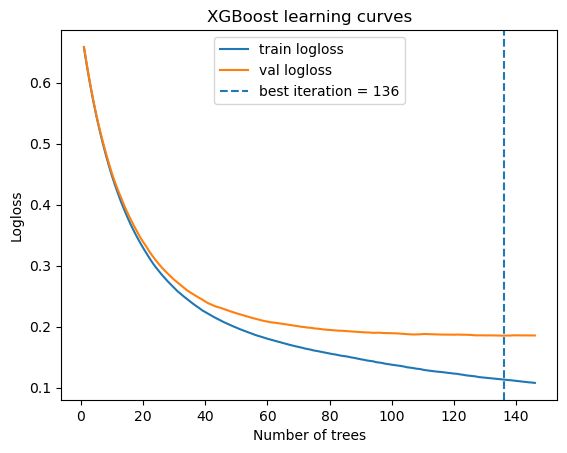

Best iteration: 136


In [215]:
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
for train_idx, val_idx in splitter.split(X_tr, y_tr, groups=group_tr):

    X_train, X_val = X_tr.iloc[train_idx], X_tr.iloc[val_idx]
    y_train, y_val = y_tr.iloc[train_idx], y_tr.iloc[val_idx]
    group_train, group_val = group_tr.iloc[train_idx], group_tr.iloc[val_idx]

#print(y_val.head(15))
# 
# Make sure eval_metric is set; set n_estimators high and rely on early stopping
if i==0:
    preset = {
        'colsample_bytree': 0.9,
        'learning_rate': 0.05,
        'max_depth': 4,
        'n_estimators': 2000,
        'scale_pos_weigth': scale2,
        'subsample': 0.8,
        "eval_metric":'logloss',
        "use_label_encoder":False,
        "verbosity":0,
        "objective":'binary:logistic', # pitäsköhä tähä tehä joku uus? 
        "early_stopping_rounds":10,
        }
elif i==1:
    preset = { 
        'colsample_bytree': 0.8,
        'learning_rate': 0.05,
        'max_depth': 5,
        'n_estimators': 2000,
        'scale_pos_weigth': scale2,
        'subsample': 0.7,
        "eval_metric":'logloss',
        "use_label_encoder":False,
        "verbosity":0,
        "objective":'binary:logistic', # pitäsköhä tähä tehä joku uus? 
        "early_stopping_rounds":10,
        }
else:
        preset = {
        'colsample_bytree': 0.9,
        'learning_rate': 0.05,
        'max_depth': 4,
        'n_estimators': 2000,
        'scale_pos_weigth': 1,
        'subsample': 0.9,
        "eval_metric":'logloss',
        "use_label_encoder":False,
        "verbosity":0,
        "objective":'binary:logistic', # pitäsköhä tähä tehä joku uus? 
        "early_stopping_rounds":10,
        }

model = XGBClassifier(**preset, seed=SEED, random_state=SEED)

model.fit(
    X_train.values, y_train.values,
    eval_set=[(X_train.values, y_train.values),
              (X_val.values,   y_val.values)],
    verbose=False
)

# --- Plot learning curves ---
results = model.evals_result()
train_loss = results['validation_0']['logloss']   # first tuple in eval_set
val_loss   = results['validation_1']['logloss']   # second tuple in eval_set
epochs = range(1, len(train_loss) + 1)

plt.figure()
plt.plot(epochs, train_loss, label='train logloss')
plt.plot(epochs, val_loss,   label='val logloss')
plt.axvline(model.best_iteration+1, linestyle='--',
            label=f'best iteration = {model.best_iteration+1}')
plt.xlabel('Number of trees')
plt.ylabel('Logloss')
plt.title('XGBoost learning curves')
plt.legend()
plt.show()

print("Best iteration:", model.best_iteration+1)
best_n_estimates = model.best_iteration+1


 for each dataset best hyperparams

In [216]:
if i==0:
    preset = {
        'colsample_bytree': 0.9,
        'learning_rate': 0.05,
        'max_depth': 4,
        'n_estimators': min(best_n_estimates, 100),
        'scale_pos_weigth': scale2,
        'subsample': 0.8,
        "eval_metric":'logloss',
        "use_label_encoder":False,
        "verbosity":0,
        "objective":'binary:logistic', # pitäsköhä tähä tehä joku uus? 
        "early_stopping_rounds":10,
        }
elif i==1:
    preset = {
        'colsample_bytree': 0.8,
        'learning_rate': 0.05,
        'max_depth': 5,
        'n_estimators': min(best_n_estimates, 100),
        'scale_pos_weigth': scale2,
        'subsample': 0.7,
        "eval_metric":'logloss',
        "use_label_encoder":False,
        "verbosity":0,
        "objective":'binary:logistic', # pitäsköhä tähä tehä joku uus? 
        "early_stopping_rounds":10,
    }
else:
    preset = {
        'colsample_bytree': 0.9,
        'learning_rate': 0.05,
        'max_depth': 4,
        'n_estimators': min(best_n_estimates, 100),
        'scale_pos_weigth': 1,
        'subsample': 0.9,
        "eval_metric":'logloss',
        "use_label_encoder":False,
        "verbosity":0,
        "objective":'binary:logistic', # pitäsköhä tähä tehä joku uus? 
        "early_stopping_rounds":10,
    } 


## Model optimization
contains
- threshold tuning
- ratio optimization
- K fold evalueation 

### Threshold tuning

selects threshold that fullfills FP > MULTI·FN

In [217]:
OVERSAMPLE = False  # possible to try oversampling using different methods
USE_PRESET = True   # possible to use pre set hyperparameters or start from empty model

In [218]:
def threshold_over_sampling(
        X_tr, y_tr, group_tr,
        multi=MULTI,
        n_folds=5,
        ratio='auto'
        ):
    thresholds = np.linspace(0, 1, 100)

    all_f1s, all_custom_f1s, all_F1_3s = [], [], []
    all_precisions, all_recalls, all_costs, all_fps, all_fns = [], [], [], [], []

    #gkf = StratifiedGroupKFold(n_splits=n_folds)
    gkf = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=SEED)


    for train_idx, val_idx in gkf.split(X_tr, y_tr, groups=group_tr):  # your group var
        X_train, X_val = X_tr.iloc[train_idx], X_tr.iloc[val_idx]
        y_train, y_val = y_tr.iloc[train_idx], y_tr.iloc[val_idx]

        if OVERSAMPLE:    
            # --- NEW: oversample train only ---
            ros = RandomOverSampler(
                sampling_strategy=ratio,   # or e.g. 0.3, {1: 5000}, ...
                random_state=SEED,
            )
            X_train_res, y_train_res = ros.fit_resample(X_train, y_train)
        else:
            X_train_res = X_train
            y_train_res = y_train

        # --- XGBoost on oversampled data ---
        if USE_PRESET:
            model = XGBClassifier(**preset, seed=SEED, random_state=SEED)
        else:
            model = XGBClassifier(early_stopping_rounds=10, seed=SEED, random_state=SEED)

        model.fit(
            X_train_res.values, y_train_res.values,
            eval_set=[(X_val.values, y_val.values)],   # val set is NOT oversampled
            verbose=False,
        )

        # --- same threshold tuning as before ---
        y_prob = model.predict_proba(X_val.values)[:, 1]

        f1s, custom_f1s, F1_3s, precisions, recalls, costs, fps, fns = \
            threshold_metrics(y_val.values, y_prob, thresholds)

        all_f1s.append(f1s)
        all_F1_3s.append(F1_3s)
        all_precisions.append(precisions)
        all_recalls.append(recalls)
        all_costs.append(costs)
        all_fps.append(fps)
        all_fns.append(fns)

    # then your aggregation code:
    all_f1s        = np.array(all_f1s)
    all_F1_3s      = np.array(all_F1_3s)
    all_precisions = np.array(all_precisions)
    all_recalls    = np.array(all_recalls)
    all_costs      = np.array(all_costs)
    all_fps        = np.array(all_fps)
    all_fns        = np.array(all_fns)

    mean_f1        = all_f1s.mean(axis=0)
    mean_F1_3      = all_F1_3s.mean(axis=0)
    mean_precision = all_precisions.mean(axis=0)
    mean_recall    = all_recalls.mean(axis=0)
    mean_costs     = all_costs.mean(axis=0)
    mean_fp        = all_fps.mean(axis=0)
    mean_fn        = all_fns.mean(axis=0)
    
    # ... your feasible-mask + plotting code exactly as in screenshot
    feasible = mean_fp <= multi * mean_fn
    print(feasible)

    if feasible.any():
        # select upper limit
        # Primary objective: minimize FP among feasible thresholds
        # inds = np.flatnonzero(feasible)  # indices where feasible is True
        # idx_best_constrained = int(inds[0])      # first True
        # print(idx_best_constrained)

        # select lower limit
        nz = np.flatnonzero(~feasible)
        idx_best_constrained = int(nz[-1])
        print(idx_best_constrained)

    else:
        # If nothing feasible, fall back to the most conservative threshold (highest thr)
        idx_best_constrained = 0.5

    thresh_best_constrained = thresholds[idx_best_constrained]

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Left axis: scores in [0,1]
    ax1.plot(thresholds, mean_f1,        label='F1')
    ax1.plot(thresholds, mean_F1_3,      label='Custom F1 (FP/3)')
    ax1.plot(thresholds, mean_precision, label='Precision')
    ax1.plot(thresholds, mean_recall,    label='Recall')
    ax1.set_xlabel('Threshold'); ax1.set_ylabel('Score'); ax1.set_ylim(0, 1); ax1.grid(True)

    # Shade infeasible region where FP > 3·FN
    ax1.fill_between(thresholds, 0, 1, where=~feasible, alpha=0.12, transform=ax1.get_xaxis_transform(),
                    label=f'Infeasible (FP > {multi}·FN)')

    # Right axis: cost curve (optional)
    ax2 = ax1.twinx()
    ax2.plot(thresholds, mean_costs, linestyle='--', label=f'Cost ({multi}·FP + FN)')
    ax2.set_ylabel(f'Cost ({multi}·FP + FN)')

    # Mark constrained-best threshold
    for ax in (ax1, ax2):
        ax.axvline(thresh_best_constrained, color='crimson', linestyle='--', linewidth=1)

    # Legends merged
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
    ax1.set_ylim(0, 1)
    ax1.set_yticks(np.arange(0, 1.01, 0.1))
    ax1.grid(True)

    # Simple annotations
    def annotate_with_arrow(ax, x, y, text, dx=0.02, dy=0.02, fmt="{:.3f}"):
        ax.annotate(
            f"{text}\n{fmt.format(x)}",
            xy=(x, y),
            xytext=(x + dx, y + dy),
            arrowprops=dict(arrowstyle='->'),
            bbox=dict(boxstyle='round', fc='w'),
        )

    annotate_with_arrow(ax2, thresh_best_constrained,  idx_best_constrained, 'Constraint best')             
    plt.tight_layout(); plt.show()

    return thresh_best_constrained


/path/to/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
/path/to/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
/path/to/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
/path/to/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
/path/to/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


[False False False False False False False False False False False False
 False False False False False False False False False  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True]
20


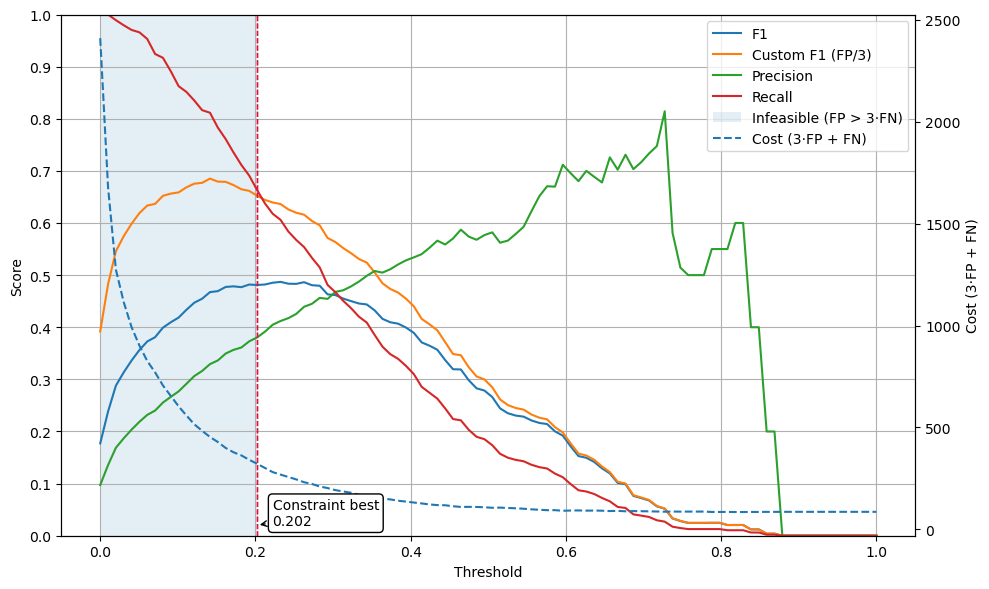

[np.float64(0.20202020202020204)]

In [219]:
if OVERSAMPLE:
    ratios = [0.2, 0.3, 0.4]
else:
    ratios = [None]

trs = []
for r in ratios:
    tr = threshold_over_sampling(
        X_tr, y_tr, group_tr,
        multi=MULTI,
        n_folds=5,
        ratio=r,
        )
    trs.append(tr)
    
trs

Cross validated results using above threshold

In [220]:
def cross_validate_thresholded_factory(
    model_factory,
    X, y,
    *,
    n_splits=5,
    threshold=0.5,
    random_state=42,
    groups=None,
    sample_ratio="auto",      # <--- NEW
    plot_cm=True,
    plot_dir=PLOT_PATH,
    title_prefix="CV fold ",
    cmap="coolwarm",
    text_color="white",
):
    rows = []
    cms_rownorm = []
    cms = []

    #gkf = GroupKFold(n_splits=n_splits)
    gkf = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=SEED)

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X_tr, y_tr, groups=group_tr)):

        # ----- split -----
        X_train, X_va = X_tr.iloc[train_idx], X_tr.iloc[val_idx]
        y_train, y_va = y_tr.iloc[train_idx], y_tr.iloc[val_idx]

        if OVERSAMPLE:
            # ----- oversample TRAINING fold only -----
            ros = RandomOverSampler(
                sampling_strategy="auto",  # or 0.3 / {1: 5000}, etc.
                random_state=random_state,
            )
            X_tr_res, y_tr_res = ros.fit_resample(X_train, y_train)
        else:
            X_tr_res = X_train
            y_tr_res = y_train

        # ----- fresh model for this fold -----
        model = model_factory()

        model.fit(
            X_tr_res.values,
            y_tr_res.values,
            eval_set=[(X_tr_res.values, y_tr_res.values),
                      (X_va.values,     y_va.values)],
            verbose=False,
        )

        # ----- evaluate on ORIGINAL (un-oversampled) validation fold -----
        y_proba_va = model.predict_proba(X_va.values)[:, 1]
        y_pred_va = proba_to_labels(y_proba_va, threshold)

        # confusion matrix (counts)
        cm = confusion_matrix(y_va, y_pred_va, labels=[0, 1])
        cms.append(cm)

        # row-normalised CM (fractions 0..1)
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums = np.where(row_sums == 0, 1, row_sums)   # avoid /0
        cm_row = cm.astype(float) / row_sums
        cms_rownorm.append(cm_row)

        # metrics for this fold
        met = {
            "fold": fold,
            "kappa":    cohen_kappa_score(y_va, y_pred_va),
            "f1":       f1_score(y_va, y_pred_va),
            "recall":   recall_score(y_va, y_pred_va),
            "precision":precision_score(y_va, y_pred_va),
            "accuracy": accuracy_score(y_va, y_pred_va),
            "customf1": custom_f1(y_va, y_pred_va),
        }
        rows.append(met)

        # optional per-fold plot
        if plot_cm:
            try:
                plot_confusion_matrix_with_percentages(
                    y_va,
                    y_pred_va,
                    percent_type="row",
                    threshold=threshold,
                    save_path=(
                        f"{plot_dir}/cv_fold_{fold}_cm_str{str(threshold).replace('.','_')}.png"
                    ),
                    title=f"{title_prefix}{fold}\nConfusion Matrix with Row %",
                    cmap=cmap,
                    text_color=text_color,
                )
            except NameError:
                # plotting helper not defined – just skip
                pass

        # quick log
        print(f"\n==== Fold {fold} ====")
        for k in ["kappa", "f1", "recall", "precision", "accuracy", "customf1"]:
            print(f"{k:>10}: {met[k]:.4f}")

    # ----- aggregate metrics over folds -----
    df = pd.DataFrame(rows).set_index("fold")
    summary = df.agg(["mean", "std"])

    print("\n==== CV Summary (val folds) ====")
    for k in ["kappa", "f1", "recall", "precision", "accuracy", "customf1"]:
        print(f"{k:>10}: {summary.loc['mean', k]:.4f} ± {summary.loc['std', k]:.4f}")

    # stack confusion matrices
    cms_rownorm = np.stack(cms_rownorm, axis=0)   # (F, 2, 2)
    cm_mean_row = cms_rownorm.mean(axis=0)
    ddof = 0 if n_splits <= 1 else 1
    cm_std_row = cms_rownorm.std(axis=0, ddof=ddof)

    cms_counts = np.stack(cms, axis=0)            # (F, 2, 2)
    mean_cnt = cms_counts.mean(axis=0)
    std_cnt = cms_counts.std(axis=0, ddof=ddof)

    # overall mean CM plot (row-normalised)
    try:
        plot_cv_mean_confusion_matrix_rowpct(
            cm_mean_row,
            std_mat=cm_std_row,
            mean_cnt=mean_cnt,
            std_cnt=std_cnt,
            title=f"{title_prefix}CV mean (± std) confusion matrix (row %)",
            threshold=threshold,
            save_path=(
                f"{plot_dir}/cv_mean_cm_rowpct.png"
            ),
            cmap=cmap,
            text_color=text_color,
        )
    except NameError:
        pass

    # return detailed results
    return df, summary, {
        "cm_mean_rowpct": cm_mean_row,
        "cm_std_rowpct": cm_std_row,
        "cm_mean_counts": mean_cnt,
        "cm_std_counts": std_cnt,
    }



=== Testing sampling_ratio = None ===


/path/to/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")



==== Fold 0 ====
     kappa: 0.4041
        f1: 0.4935
    recall: 0.7525
 precision: 0.3671
  accuracy: 0.8276
  customf1: 0.6888


/path/to/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")



==== Fold 1 ====
     kappa: 0.3328
        f1: 0.4093
    recall: 0.6310
 precision: 0.3029
  accuracy: 0.8456
  customf1: 0.5966


...


==== Fold 3 ====
     kappa: 0.3974
        f1: 0.4701
    recall: 0.6484
 precision: 0.3688
  accuracy: 0.8616
  customf1: 0.6425


/path/to/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")



==== Fold 4 ====
     kappa: 0.4604
        f1: 0.5208
    recall: 0.6410
 precision: 0.4386
  accuracy: 0.8888
  customf1: 0.6696

==== CV Summary (val folds) ====
     kappa: 0.4090 ± 0.0507
        f1: 0.4823 ± 0.0457
    recall: 0.6670 ± 0.0491
 precision: 0.3805 ± 0.0541
  accuracy: 0.8598 ± 0.0241
  customf1: 0.6546 ± 0.0365
Mean custom F1 for sampling_ratio=None: 0.6546

Best sampling_ratio: None
Scores: {None: np.float64(0.654610485404137)}
Optimal threshold: 0.2


/tmp/ipykernel_18665/607131370.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat([metrics_df, row], ignore_index=True)


,data,F1_score,kappa,recall,precision,accuracy,customf1,specificity,PNV
0,training_Kfold_eval,0.482298,None,0.667029,0.380471,0.859817,0.65461,None,None


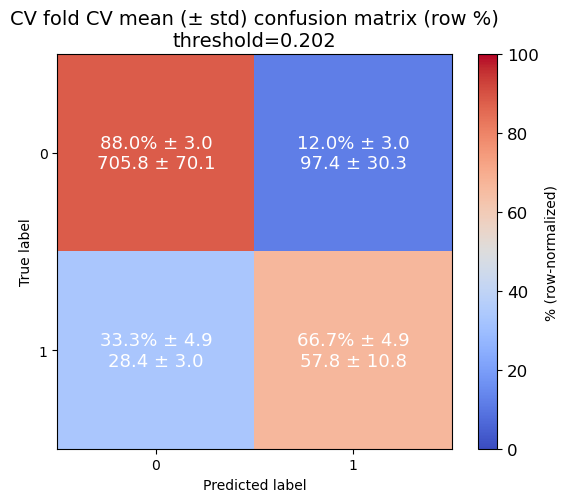

In [221]:


def model_factory():
    """Return a NEW, un-fitted XGBClassifier each time."""
    if USE_PRESET:
        return XGBClassifier(**preset)
    else:
        return XGBClassifier(early_stopping_rounds=80)

results_by_ratio = {}
for index, (r, t) in enumerate(zip(ratios, trs)):
    print(f"\n=== Testing sampling_ratio = {r} ===")
    cv_results, cv_summary, stats = cross_validate_thresholded_factory(
        model_factory,
        X_tr,
        y_tr,
        n_splits=5,
        threshold=t,
        groups=group_tr,
        sample_ratio=r,         # <--- here
        plot_cm=False,          # keep False to avoid tons of plots
    )

    mean_f1 = cv_summary.loc["mean", "customf1"]
    results_by_ratio[r] = mean_f1
    print(f"Mean custom F1 for sampling_ratio={r}: {mean_f1:.4f}")

best_ratio = max(results_by_ratio, key=results_by_ratio.get)
print("\nBest sampling_ratio:", best_ratio)
print("Scores:", results_by_ratio)

THRESHOLD = trs[ratios.index(best_ratio)]
THRESHOLD = round(THRESHOLD, 2)
print("Optimal threshold:", THRESHOLD)

if not OVERSAMPLE:

    row = pd.DataFrame({'data':['training_Kfold_eval'], 
                        'F1_score':[cv_summary.loc["mean", "f1"]], 
                        'kappa':[None], 
                        'recall':[cv_summary.loc["mean", "recall"]], 
                        'precision':[cv_summary.loc["mean", "precision"]], 
                        'accuracy':[cv_summary.loc["mean", "accuracy"]], 
                        'customf1':[cv_summary.loc["mean", "customf1"]], 
                        'specificity':[None], 
                        'PNV':[None]})
    metrics_df = pd.concat([metrics_df, row], ignore_index=True)
    metrics_df


## Actual model training

Whole data training before test

In [222]:
from xgboost import XGBClassifier
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)

for train_idx, val_idx in splitter.split(X_tr, y_tr, groups=group_tr):
    X_train, X_val = X_tr.iloc[train_idx], X_tr.iloc[val_idx]
    y_train, y_val = y_tr.iloc[train_idx], y_tr.iloc[val_idx]

    if OVERSAMPLE:
    # ----- NEW: oversample training set only -----
        ros = RandomOverSampler(
            sampling_strategy=best_ratio,   # or 0.3 / {1: 5000} etc.
            random_state=SEED,
        )
        X_train_res, y_train_res = ros.fit_resample(X_train, y_train)
    else:
        X_train_res = X_train
        y_train_res = y_train
    print(
        f"X_train: {X_train_res.shape}, y_train: {y_train_res.shape}, "
        f"X_val: {X_val.shape}, y_val: {y_val.shape}"
    )

    if USE_PRESET:
        best_model = XGBClassifier(**preset, seed=SEED)
    else:
        best_model = XGBClassifier(early_stopping_rounds=10)
    #best_model = XGBClassifier()

    best_model.fit(
        X_train_res.values,
        y_train_res.values,
        eval_set=[(X_train_res.values, y_train_res.values),
                  (X_val.values,       y_val.values)],
        verbose=False,
    )

# use original (un-oversampled) val set for metrics / threshold tuning
y_pred  = best_model.predict(X_val.values)
y_proba = best_model.predict_proba(X_val.values)[:, 1]


X_train: (3504, 272), y_train: (3504,), X_val: (943, 272), y_val: (943,)


/path/to/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, early_stopping_rounds=10,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, predictor=None, random_state=None, ...)

save model

In [223]:
# load the model for later use
# save the model (JSON or binary)
best_model.save_model(DATA_PATH + "xgb_model.json")
# save the feature names so R can pick them up
import json
with open(DATA_PATH + "features.json", "w") as f:
    json.dump(list(X_train.columns), f)

### Training evaluation

array([0.00542152, 0.00546481, 0.00669872, ..., 0.00467254, 0.00796857,
       0.01193199], shape=(3504,), dtype=float32)

<Figure size 800x700 with 0 Axes>

Text(0.5, 0, 'False Positive Rate')

Text(0, 0.5, 'True Positive Rate')

Text(0.5, 1.0, 'ROC Curve')

(array([-0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(-0.2, 0, '−0.2'),
  Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4000000000000001, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0000000000000002, 0, '1.0'),
  Text(1.2000000000000002, 0, '1.2')])

(array([-0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(0, -0.2, '−0.2'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4000000000000001, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0000000000000002, '1.0'),
  Text(0, 1.2000000000000002, '1.2')])

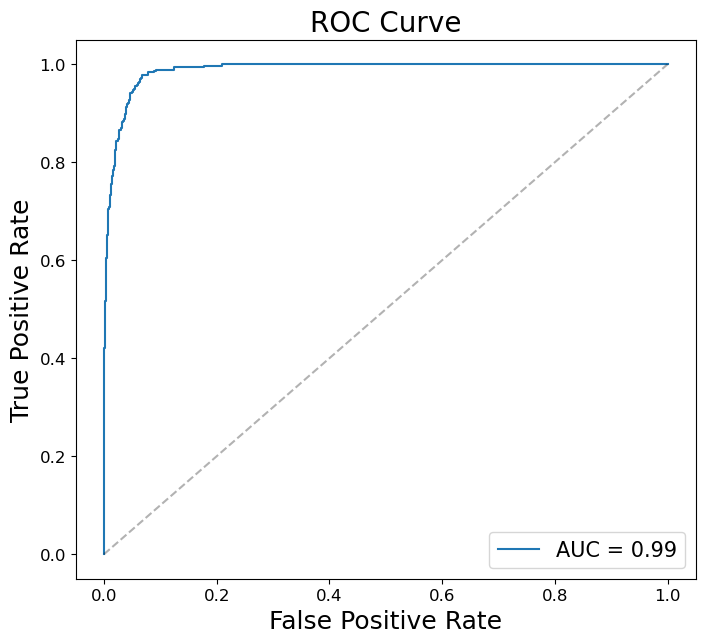

<Figure size 800x700 with 0 Axes>

Text(0.5, 0, 'Recall')

Text(0, 0.5, 'Precision')

Text(0.5, 1.0, 'Precision-Recall Curve')

(array([-0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(-0.2, 0, '−0.2'),
  Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4000000000000001, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0000000000000002, 0, '1.0'),
  Text(1.2000000000000002, 0, '1.2')])

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0, '1.0'),
  Text(0, 1.2000000000000002, '1.2')])

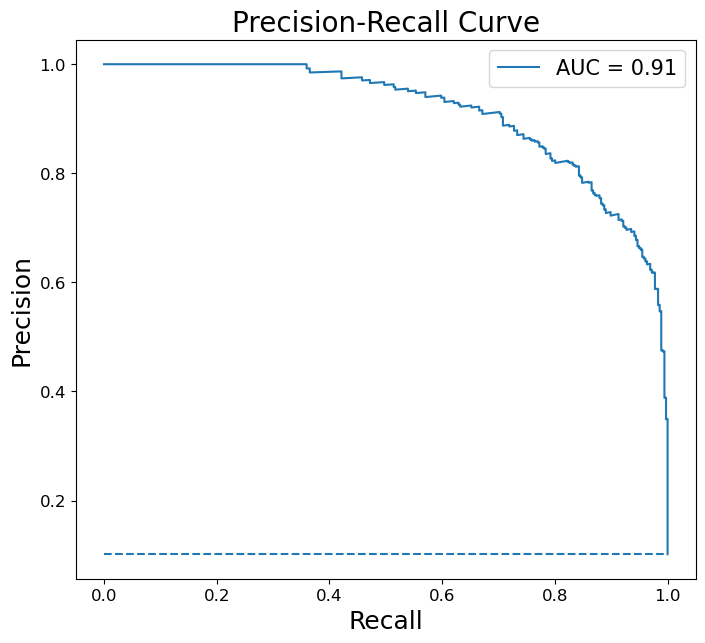

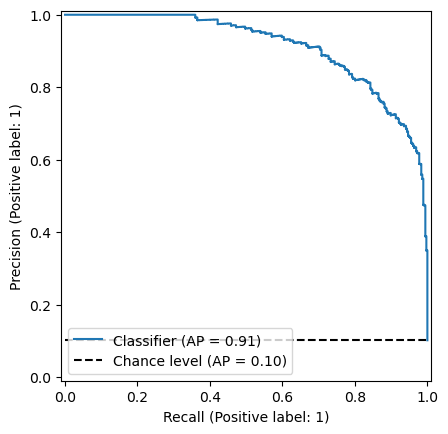

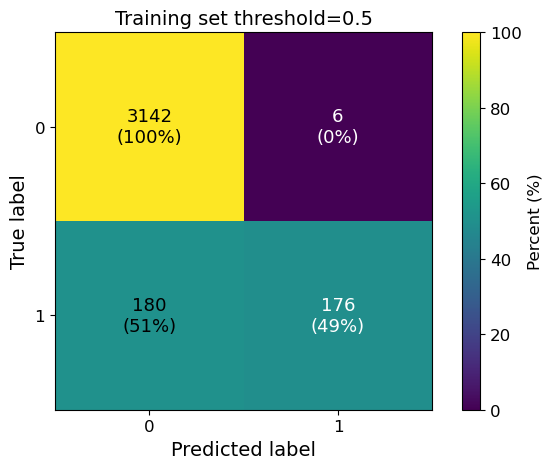

Kappa: 0.6287560493242073
Recall: 0.4943820224719101
Precision: 0.967032967032967
F1 score: 0.654275092936803
Custom F1: 0.6592

CM with custom threshold:


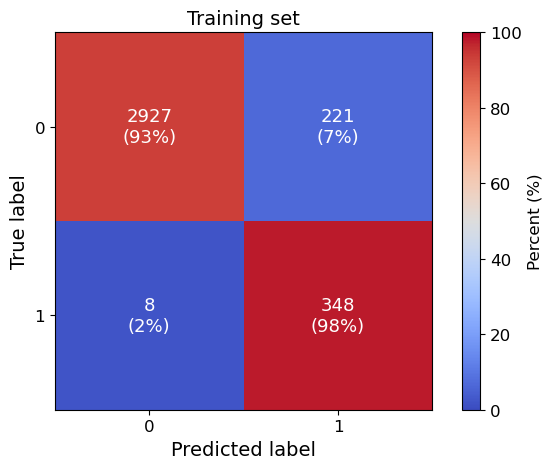

/tmp/ipykernel_18665/2273364891.py:101: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat([metrics_df, row], ignore_index=True)


,data,F1_score,kappa,recall,precision,accuracy,customf1,specificity,PNV
0,training_Kfold_eval,0.482298,NaN,0.667029,0.380471,0.859817,0.654610,NaN,NaN
1,training,0.752432,0.717068,0.977528,0.611599,0.934646,0.894985,0.929797,0.997274


Kappa: 0.7170678318463001
Recall: 0.9775280898876404
Precision: 0.6115992970123023
F1 score: 0.7524324324324324
Custom F1: 0.8950


In [224]:

# -------------------------------ROC curve-------------------------------
y_prob_train = best_model.predict_proba(X_train)[:, 1]
y_prob_train
fpr, tpr, _ = roc_curve(y_train, y_prob_train)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel("False Positive Rate", fontsize=18)
plt.ylabel("True Positive Rate", fontsize=18)
plt.title("ROC Curve", fontsize=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=15)
plt.savefig(PLOT_PATH+'train/ROC_curve', dpi=300, bbox_inches='tight')
plt.show()

# Threshold tuning
y_prob_train = best_model.predict_proba(X_train)[:, 1] # test probabilities from 0 to 1 
precision, recall, thresholds = precision_recall_curve(y_train, y_prob_train) # calculates scores

aucc = round(auc(recall, precision),2)



# --------------------------Plot precision-recall curve--------------------------
plt.figure(figsize=(8, 7))
plt.plot(recall, precision, label=f'AUC = {aucc}')
#plt.plot([1, 0], [0, 1], 'k--', alpha=0.3)
baseline = y_train.sum() / len(y_train)
plt.hlines(baseline, 0, 1, linestyles='--')
plt.xlabel('Recall', fontsize=18)
plt.ylabel('Precision', fontsize=18)
plt.title('Precision-Recall Curve', fontsize=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=15)
plt.savefig(PLOT_PATH+'train/PR_curve', dpi=300, bbox_inches='tight')
plt.show()


# -------------------------- PR another way ----------------------------------------------
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_train, y_prob_train, plot_chance_level=True)

# --------------------------Confusion matrices--------------------------

y_pred_train = best_model.predict(X_train)


plot_confusion_matrix_with_percentages(
    y_train, y_pred_train, 
    percent_type='row', 
    threshold=None,
    save_path= PLOT_PATH+'train/cm_0_5',
    title="Training set threshold=0.5"
)

kappa = cohen_kappa_score(y_train, y_pred_train)
recall = recall_score(y_train, y_pred_train)
precision = precision_score(y_train, y_pred_train)
f1 = f1_score(y_train, y_pred_train)
accuracy = accuracy_score(y_train, y_pred_train)
customf1 = custom_f1(y_train, y_pred_train)
spec = recall_score(y_train, y_pred_train, pos_label=0)



print('Kappa:', kappa) # Is my model better than random, and by how much?
print("Recall:", recall)
print("Precision:", precision)
print("F1 score:", f1)
print(f"Custom F1: {customf1:.4f}")

print()
print("CM with custom threshold:")
y_pred_thresh = (y_prob_train >= THRESHOLD).astype(int)

plot_confusion_matrix_with_percentages(
    y_train, y_pred_thresh, 
    percent_type='row', 
    threshold=None,
    save_path= PLOT_PATH+'train/cm_mod_tr',
    title='Training set',
    cmap='coolwarm',
    text_color='white'
    )

kappa = cohen_kappa_score(y_train, y_pred_thresh)
recall = recall_score(y_train, y_pred_thresh)
precision = precision_score(y_train, y_pred_thresh)
f1 = f1_score(y_train, y_pred_thresh)
accuracy = accuracy_score(y_train, y_pred_thresh)
customf1 = custom_f1(y_train, y_pred_thresh)
spec = recall_score(y_train, y_pred_thresh, pos_label=0)
pnv = calc_pnv(y_train, y_pred_thresh)


row = pd.DataFrame({'data':[f'training'], 'F1_score':[f1], 'kappa':[kappa], 'recall':[recall], 'precision':[precision], 'accuracy':[accuracy], 'customf1':[customf1], 'specificity':[spec], 'PNV':[pnv]})
metrics_df = pd.concat([metrics_df, row], ignore_index=True)
metrics_df

print('Kappa:', kappa) # Is my model better than random, and by how much?
print("Recall:", recall)
print("Precision:", precision)
print("F1 score:", f1)
print(f"Custom F1: {customf1:.4f}")


One day early correction + custom threshold

f1 before mod: 0.7524324324324324
Kappa       : 0.7957
F1 Score    : 0.8198
Recall      : 0.9775
Accuracy    : 0.9563
Precision   : 0.7059
Custom F1   : 0.9251


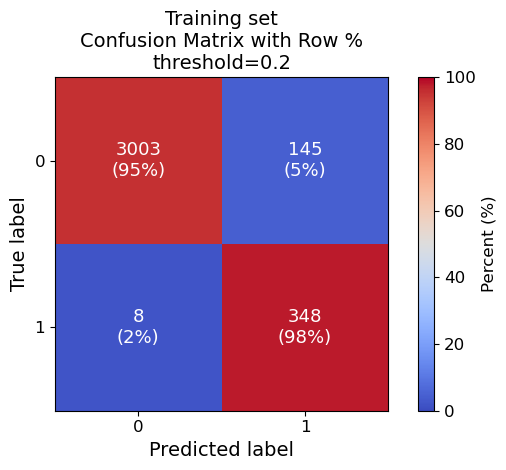

,data,F1_score,kappa,recall,precision,accuracy,customf1,specificity,PNV
0,training_Kfold_eval,0.482298,NaN,0.667029,0.380471,0.859817,0.654610,NaN,NaN
1,training,0.752432,0.717068,0.977528,0.611599,0.934646,0.894985,0.929797,0.997274
2,train_corrected,0.819788,0.795680,0.977528,0.705882,0.956336,0.925122,0.953939,0.997343


In [225]:
y_prob_train = best_model.predict_proba(X_train)[:, 1]

df, score, y_pred_mod = custom_score(y_train, y_prob_train, group_train , threshold=THRESHOLD, eval=True)

# Evaluation metrics
f1 = f1_score(y_train, y_pred_mod)
recall = recall_score(y_train, y_pred_mod)
accuracy = accuracy_score(y_train, y_pred_mod)
precision = precision_score(y_train, y_pred_mod)
kappa = cohen_kappa_score(y_train, y_pred_mod)
spec = recall_score(y_train, y_pred_mod, pos_label=0)
pnv = calc_pnv(y_train, y_pred_mod)

print(f"Kappa       : {kappa:.4f}")
print(f"F1 Score    : {f1:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
customf1 = custom_f1(y_train, y_pred_mod)
print(f"Custom F1   : {customf1:.4f}")


# Confusion matrix
plot_confusion_matrix_with_percentages(
    y_train, y_pred_mod, 
    percent_type='row', 
    threshold=None,
    save_path= PLOT_PATH+'train/one_day_early_correction_cm',
    title=f'Training set\nConfusion Matrix with Row %\nthreshold={str(THRESHOLD)}',
    cmap='coolwarm',
    text_color='white'

)

row = pd.DataFrame({'data':[f'train_corrected'], 'F1_score':[f1], 'kappa':[kappa], 'recall':[recall], 'precision':[precision], 'accuracy':[accuracy], 'customf1':[customf1], 'specificity':[spec], 'PNV':[pnv]})
metrics_df = pd.concat([metrics_df, row], ignore_index=True)
metrics_df


## Test

### Test set evaluation

In [226]:
y_pred_test = best_model.predict(X_test)
print('Kappa:', cohen_kappa_score(y_test, y_pred_test))
print("Recall:", recall_score(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test))
print("F1 score:", f1_score(y_test, y_pred_test))
customf1 = custom_f1(y_test, y_pred_test)
print(f"Custom F1: {customf1:.4f}")

Kappa: 0.34100746101666746
Recall: 0.26605504587155965
Precision: 0.6590909090909091
F1 score: 0.3790849673202614
Custom F1: 0.4056


array([0.00462411, 0.00451308, 0.00471113, ..., 0.0875606 , 0.23486683,
       0.12264196], shape=(1085,), dtype=float32)

<Figure size 800x700 with 0 Axes>

Text(0.5, 0, 'False Positive Rate')

Text(0, 0.5, 'True Positive Rate')

Text(0.5, 1.0, 'ROC Curve')

(array([-0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(-0.2, 0, '−0.2'),
  Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4000000000000001, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0000000000000002, 0, '1.0'),
  Text(1.2000000000000002, 0, '1.2')])

(array([-0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(0, -0.2, '−0.2'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4000000000000001, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0000000000000002, '1.0'),
  Text(0, 1.2000000000000002, '1.2')])

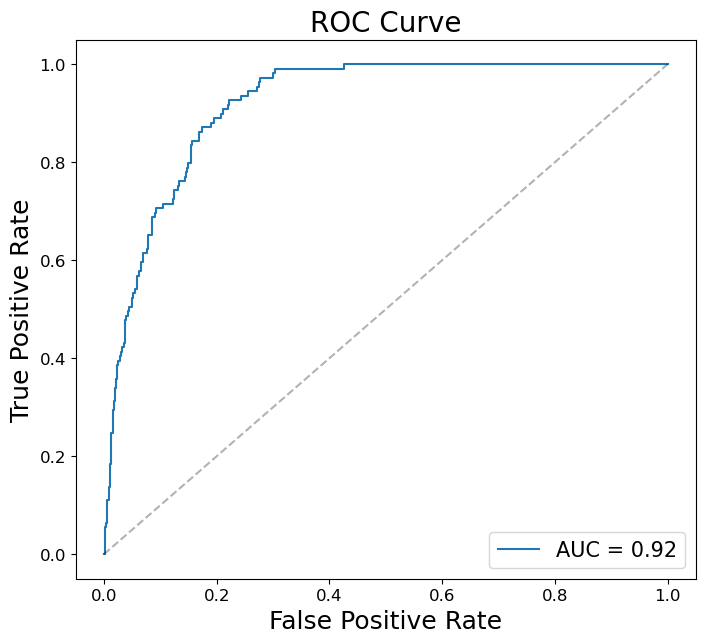

<Figure size 800x700 with 0 Axes>

Text(0.5, 0, 'Recall')

Text(0, 0.5, 'Precision')

Text(0.5, 1.0, 'Precision-Recall Curve')

(array([-0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(-0.2, 0, '−0.2'),
  Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4000000000000001, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0000000000000002, 0, '1.0'),
  Text(1.2000000000000002, 0, '1.2')])

(array([-0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(0, -0.2, '−0.2'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4000000000000001, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0000000000000002, '1.0'),
  Text(0, 1.2000000000000002, '1.2')])

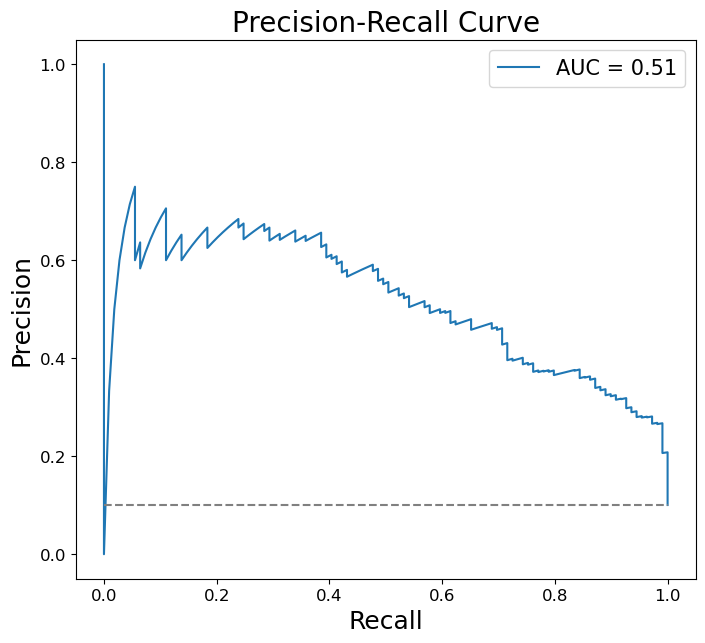

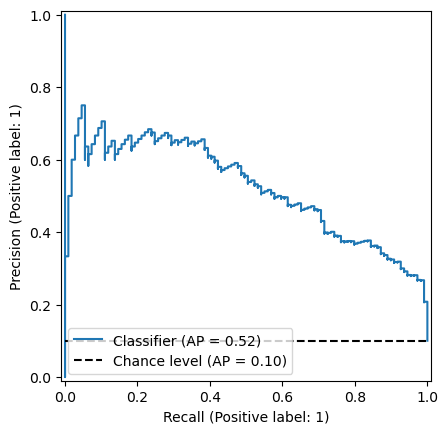

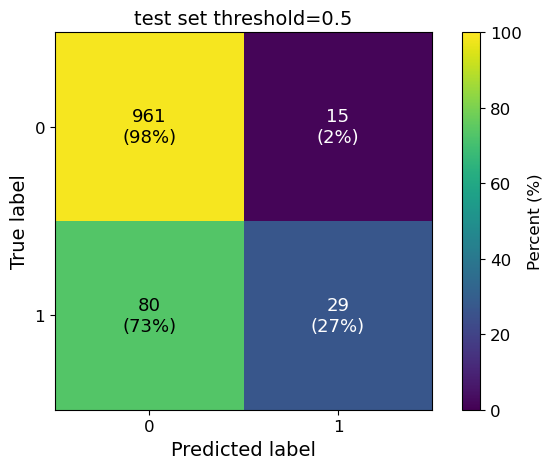

Kappa: 0.34100746101666746
Recall: 0.26605504587155965
Precision: 0.6590909090909091
F1 score: 0.3790849673202614
Accuracy: 0.9124423963133641
Custom F1   : 0.4056

CM with custom threshold:


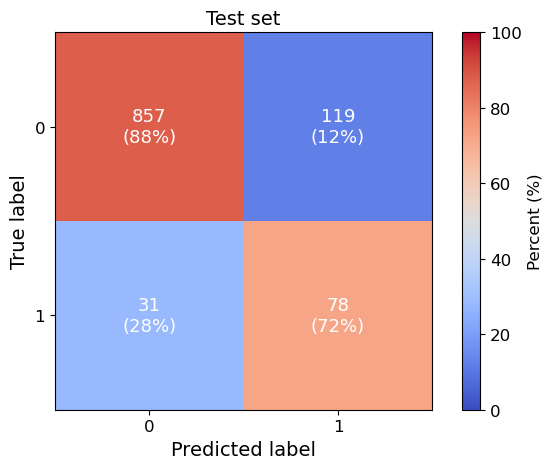

,data,F1_score,kappa,recall,precision,accuracy,customf1,specificity,PNV
0,training_Kfold_eval,0.482298,NaN,0.667029,0.380471,0.859817,0.654610,NaN,NaN
1,training,0.752432,0.717068,0.977528,0.611599,0.934646,0.894985,0.929797,0.997274
2,train_corrected,0.819788,0.795680,0.977528,0.705882,0.956336,0.925122,0.953939,0.997343
3,test,0.509804,0.436976,0.715596,0.395939,0.861751,0.688235,0.878074,0.965090


Kappa: 0.4369758946115738
Recall: 0.7155963302752294
Precision: 0.39593908629441626
F1 score: 0.5098039215686274
Accuracy: 0.8617511520737328
Custom F1: 0.6882


In [227]:

# ROC curve
y_prob_test = best_model.predict_proba(X_test)[:, 1]
y_prob_test
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel("False Positive Rate", fontsize=18)
plt.ylabel("True Positive Rate", fontsize=18)
plt.title("ROC Curve", fontsize=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=15)
plt.savefig(PLOT_PATH+'test/ROC_curve', dpi=300, bbox_inches='tight')
plt.show()

# Threshold tuning
y_prob_test = best_model.predict_proba(X_test)[:, 1] # test probabilities from 0 to 1 
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_test) # calculates scores

aucc = round(auc(recall, precision),2)

# Plot precision-recall curve
plt.figure(figsize=(8, 7))
plt.plot(recall, precision, label=f'AUC = {aucc}')
#plt.plot([1, 0], [0, 1], 'k--', alpha=0.3)
baseline = y_test.sum() / len(y_test)
plt.hlines(baseline, 0, 1, linestyles='--', colors='grey')
plt.xlabel('Recall', fontsize=18)
plt.ylabel('Precision', fontsize=18)
plt.title('Precision-Recall Curve', fontsize=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=15)
plt.savefig(PLOT_PATH+'test/PR_curve', dpi=300, bbox_inches='tight')
plt.show()

# -------------------------- PR another way ----------------------------------------------
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_prob_test, plot_chance_level=True)


# --------------------------Confusion matrices--------------------------

# Test confusion matrix using basic treshold (0.5)
plot_confusion_matrix_with_percentages(
    y_test, y_pred_test, 
    percent_type='row', 
    threshold=None,
    save_path= PLOT_PATH+'test/cm_0_5',
    title="test set threshold=0.5"
)

kappa = cohen_kappa_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
accuracy = accuracy_score(y_test, y_pred_test)
f1_mod = custom_f1(y_test, y_pred_test, multi=MULTI)
customf1 = custom_f1(y_test, y_pred_test)


print('Kappa:', kappa) # Is my model better than random, and by how much?
print("Recall:", recall)
print("Precision:", precision)
print("F1 score:", f1)
print("Accuracy:", accuracy)
print(f"Custom F1   : {customf1:.4f}")

print()
print("CM with custom threshold:")
# Test confusion matrix using custom treshold
y_pred_thresh = (y_prob_test >= THRESHOLD).astype(int)

plot_confusion_matrix_with_percentages(
    y_test, y_pred_thresh, 
    percent_type='row', 
    threshold=None,
    save_path= PLOT_PATH+'test/cm_'+str(THRESHOLD).replace('.', '_'),
    title=f"Test set",
    cmap='coolwarm',
    text_color='white'
)

kappa = cohen_kappa_score(y_test, y_pred_thresh)
recall = recall_score(y_test, y_pred_thresh)
precision = precision_score(y_test, y_pred_thresh)
f1 = f1_score(y_test, y_pred_thresh)
accuracy = accuracy_score(y_test, y_pred_thresh)
f1_mod = custom_f1(y_test, y_pred_thresh, multi=MULTI)
spec = recall_score(y_test, y_pred_thresh, pos_label=0)
pnv = calc_pnv(y_test, y_pred_thresh)
customf1 = custom_f1(y_test, y_pred_thresh)


row = pd.DataFrame({'data':[f'test'], 'F1_score':[f1], 'kappa':[kappa], 'recall':[recall], 'precision':[precision], 'accuracy':[accuracy], 'customf1':[customf1], 'specificity':[spec], 'PNV':[pnv]})
metrics_df = pd.concat([metrics_df, row], ignore_index=True)
metrics_df

print('Kappa:', kappa) # Is my model better than random, and by how much?
print("Recall:", recall)
print("Precision:", precision)
print("F1 score:", f1)
print("Accuracy:", accuracy)
print(f"Custom F1: {customf1:.4f}")




One day early correction

f1 before mod: 0.5098039215686274
Kappa       : 0.4976
F1 Score    : 0.5591
Recall      : 0.7156
Accuracy    : 0.8866
Precision   : 0.4588
Custom F1   : 0.7167


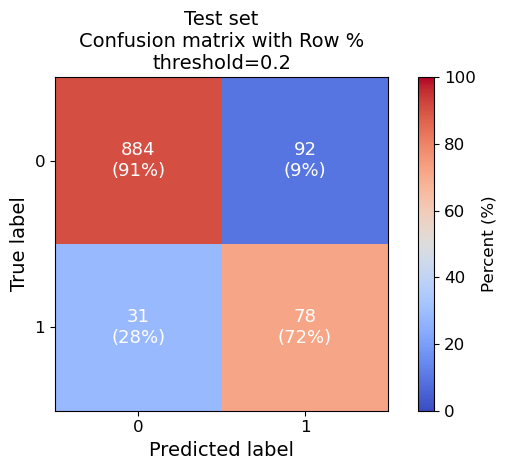

,data,F1_score,kappa,recall,precision,accuracy,customf1,specificity,PNV
0,training_Kfold_eval,0.482298,NaN,0.667029,0.380471,0.859817,0.654610,NaN,NaN
1,training,0.752432,0.717068,0.977528,0.611599,0.934646,0.894985,0.929797,0.997274
2,train_corrected,0.819788,0.795680,0.977528,0.705882,0.956336,0.925122,0.953939,0.997343
3,test,0.509804,0.436976,0.715596,0.395939,0.861751,0.688235,0.878074,0.965090
4,test_corrected,0.559140,0.497638,0.715596,0.458824,0.886636,0.716692,0.905738,0.966120


In [228]:
y_prob_test = best_model.predict_proba(X_test)[:, 1]
df, score, y_pred_mod = custom_score(y_test, y_prob_test, group_test, threshold=THRESHOLD, eval=True)
#df, score, y_pred_mod = custom_score(y_test, y_prob_test, group_test, threshold=0.04, eval=True)

# Evaluation metrics
f1 = f1_score(y_test, y_pred_mod)
recall = recall_score(y_test, y_pred_mod)
accuracy = accuracy_score(y_test, y_pred_mod)
precision = precision_score(y_test, y_pred_mod)
kappa = cohen_kappa_score(y_test, y_pred_mod)
customf1 = custom_f1(y_test, y_pred_mod)
spec = recall_score(y_test, y_pred_mod, pos_label=0)
pnv = calc_pnv(y_test, y_pred_mod)


print(f"Kappa       : {kappa:.4f}")
print(f"F1 Score    : {f1:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Custom F1   : {customf1:.4f}")


# Confusion matrix
plot_confusion_matrix_with_percentages(
    y_test, y_pred_mod, 
    percent_type='row', 
    threshold=None,
    save_path= PLOT_PATH+'test/one_day_early_correction/cm_mod_test',
    title=f"Test set\nConfusion matrix with Row %\nthreshold={str(THRESHOLD)}",
    cmap='coolwarm',
    text_color='white'
)

row = pd.DataFrame({'data':[f'test_corrected'], 'F1_score':[f1], 'kappa':[kappa], 'recall':[recall], 'precision':[precision], 'accuracy':[accuracy], 'customf1':[customf1], 'specificity':[spec], 'PNV':[pnv]})
metrics_df = pd.concat([metrics_df, row], ignore_index=True)
metrics_df


In [229]:
# all metrics to same table
eval_df = df_test.copy()
eval_df['modified_y'] = y_pred_mod
eval_df['original_y'] = y_pred_thresh
move_column_inplace(eval_df, 'modified_y', 1)
move_column_inplace(eval_df, 'original_y', 1)
move_column_inplace(eval_df, 'naytteenotto_hetki', 5)

changed_df = eval_df.loc[eval_df['original_y'] != eval_df['modified_y']]
changed_df.to_csv(DATA_PATH + "one_day_early.csv")
#changed_df

### Create evaluation df

In [230]:
# study misclassified
y_pred_thresh = (y_prob_test >= THRESHOLD).astype(int)       # Convert to class labels

# 2. Create a new DataFrame to analyze results
results_df = X_test.copy()
results_df['true_label'] = y_test.values
results_df['predicted_label'] = y_pred_thresh
results_df['prediction_proba'] = y_prob_test
results_df['id'] = group_test


# 3. Filter for misclassified rows
misclassified = results_df[results_df['true_label'] != results_df['predicted_label']]

### Calibration curve

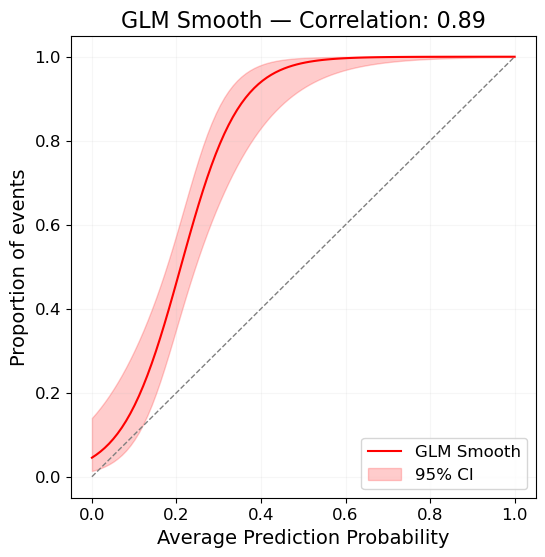

                 Generalized Linear Model Regression Results                  
Dep. Variable:              true_rate   No. Observations:                  110
Model:                            GLM   Df Residuals:                      108
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -40.004
Date:                Wed, 25 Feb 2026   Deviance:                       13.863
Time:                        08:31:37   Pearson chi2:                     13.2
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3073
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.0479      0.629     -4.848      0.0

In [231]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import pearsonr

def forced_proportion_glm(df, proba_column='prediction_proba', true_column='true_label',
                          sample_size=10, points_per_group=10, random_state=None):
    np.random.seed(random_state)

    df_pos = df[df[true_column] == 1]
    df_neg = df[df[true_column] == 0]

    avg_probas = []
    true_rates = []

    for true_count in range(sample_size + 1):
        for _ in range(points_per_group):
            if len(df_pos) < true_count or len(df_neg) < (sample_size - true_count):
                continue

            pos_sample = df_pos.sample(true_count, replace=False)
            neg_sample = df_neg.sample(sample_size - true_count, replace=False)

            sample = pd.concat([pos_sample, neg_sample])
            avg_proba = sample[proba_column].mean()

            avg_probas.append(avg_proba)
            true_rates.append(true_count / sample_size)

    result_df = pd.DataFrame({
        'avg_proba': avg_probas,
        'true_rate': true_rates
    })

    # Fit GLM
    glm_binom = sm.GLM(result_df['true_rate'], sm.add_constant(result_df['avg_proba']), 
                       family=sm.families.Binomial())
    glm_result = glm_binom.fit()

    # Predict + Confidence Interval
    pred_x = np.linspace(0, 1, 100)
    pred_y = glm_result.predict(sm.add_constant(pred_x))

    pred_summary = glm_result.get_prediction(sm.add_constant(pred_x)).summary_frame(alpha=0.05)
    pred_lower = pred_summary['mean_ci_lower']
    pred_upper = pred_summary['mean_ci_upper']

    corr_coef, _ = pearsonr(result_df['avg_proba'], result_df['true_rate'])

    # Plot
    plt.figure(figsize=(6, 6))
    plt.plot(pred_x, pred_y, color='red', label='GLM Smooth')
    plt.fill_between(pred_x, pred_lower, pred_upper, color='red', alpha=0.2, label='95% CI')
    plt.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1)
    plt.xlabel("Average Prediction Probability", fontsize=14)
    plt.ylabel(f"Proportion of events", fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, alpha=0.1)
    plt.legend(fontsize=12)
    plt.title(f"GLM Smooth — Correlation: {corr_coef:.2f}", fontsize=16)
    plt.savefig(PLOT_PATH+"test/forced_proportion_glm_plot.png", dpi=300, bbox_inches='tight')
    plt.show()

    return result_df, glm_result.summary()

individual = results_df[['id', 'cycle_number', 'true_label', 'predicted_label', 'prediction_proba', 'sykli_IND']]
result_df, glm_summary = forced_proportion_glm(individual, sample_size=10, points_per_group=10, random_state=SEED)
print(glm_summary)


### Induction eval

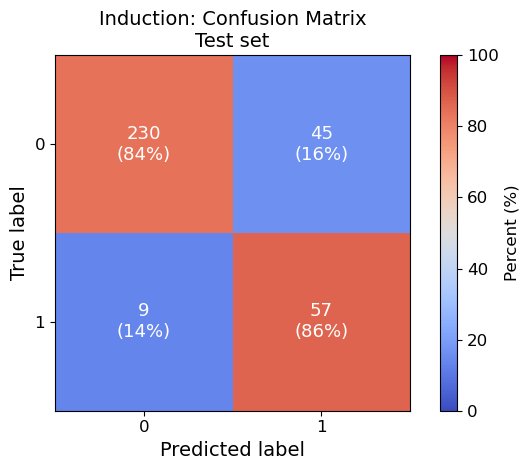

,data,F1_score,kappa,recall,precision,accuracy,customf1,specificity,PNV
0,training_Kfold_eval,0.482298,nan,0.667029,0.380471,0.859817,0.654610,nan,nan
1,training,0.752432,0.717068,0.977528,0.611599,0.934646,0.894985,0.929797,0.997274
2,train_corrected,0.819788,0.795680,0.977528,0.705882,0.956336,0.925122,0.953939,0.997343
3,test,0.509804,0.436976,0.715596,0.395939,0.861751,0.688235,0.878074,0.965090
4,test_corrected,0.559140,0.497638,0.715596,0.458824,0.886636,0.716692,0.905738,0.966120
5,IND,0.606383,0.474335,0.863636,0.467213,0.782991,0.788018,0.763636,0.958904
6,IND_corrected,0.678571,0.579819,0.863636,0.558824,0.841642,0.826087,0.836364,0.962343


In [232]:
# we can use earlier created eval_df
ind = eval_df.loc[eval_df['sykli_IND']==1]

#df, score, y_pred_mod = custom_score(ind['y_true'], y_prob_test, group_test, threshold=0.29, eval=True)
y_test = ind['infektion_binary']
y_pred_mod = ind['modified_y']
y_pred_ = ind['original_y']

# 👉 3. Evaluation metrics
f1 = f1_score(y_test, y_pred_mod)
recall = recall_score(y_test, y_pred_mod)
accuracy = accuracy_score(y_test, y_pred_mod)
precision = precision_score(y_test, y_pred_mod)

# build a metrics table
rows = pd.DataFrame({
    'data':['IND', 'IND_corrected'],
    'F1_score': [f1_score(y_test, y_pred_), f1_score(y_test, y_pred_mod)],
    'kappa' : [cohen_kappa_score(y_test, y_pred_), cohen_kappa_score(y_test, y_pred_mod)],
    'recall': [recall_score(y_test, y_pred_), recall_score(y_test, y_pred_mod)],
    'precision' : [precision_score(y_test, y_pred_), precision_score(y_test, y_pred_mod)],
    'accuracy' : [accuracy_score(y_test, y_pred_), accuracy_score(y_test, y_pred_mod)],
    'customf1' : [custom_f1(y_test, y_pred_), custom_f1(y_test, y_pred_mod)],
    'specificity':[recall_score(y_test, y_pred_, pos_label=0), recall_score(y_test, y_pred_mod, pos_label=0)],
    'PNV':[calc_pnv(y_test, y_pred_), calc_pnv(y_test, y_pred_mod)]

})
metrics_df = pd.concat([metrics_df, rows], ignore_index=True)

plot_confusion_matrix_with_percentages(
    y_test, y_pred_mod, 
    percent_type='row', 
    threshold=THRESHOLD,
    title='Induction: Confusion Matrix\nTest set',
    save_path=PLOT_PATH+'test/cm_induction_correction',
    cmap='coolwarm',
    text_color='white'
)

from IPython.display import display
display(metrics_df.style.format({"Value": "{:.4f}"}))


### Consolidation eval

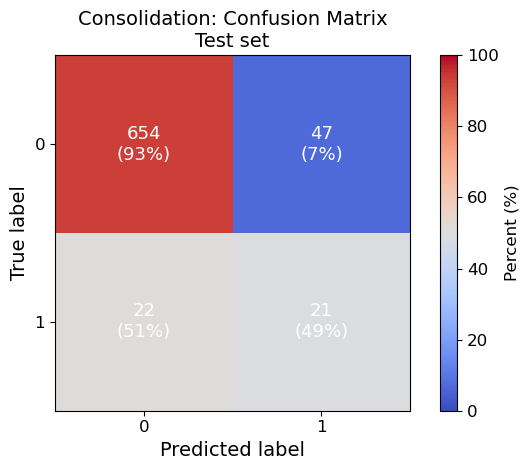

,data,F1_score,kappa,recall,precision,accuracy,customf1,specificity,PNV
0,training_Kfold_eval,0.482298,nan,0.667029,0.380471,0.859817,0.654610,nan,nan
1,training,0.752432,0.717068,0.977528,0.611599,0.934646,0.894985,0.929797,0.997274
2,train_corrected,0.819788,0.795680,0.977528,0.705882,0.956336,0.925122,0.953939,0.997343
3,test,0.509804,0.436976,0.715596,0.395939,0.861751,0.688235,0.878074,0.965090
4,test_corrected,0.559140,0.497638,0.715596,0.458824,0.886636,0.716692,0.905738,0.966120
5,IND,0.606383,0.474335,0.863636,0.467213,0.782991,0.788018,0.763636,0.958904
6,IND_corrected,0.678571,0.579819,0.863636,0.558824,0.841642,0.826087,0.836364,0.962343
7,KONS,0.355932,0.304861,0.488372,0.280000,0.897849,0.512195,0.922967,0.967115
8,KONS_corrected,0.378378,0.331005,0.488372,0.308824,0.907258,0.527197,0.932953,0.967456


In [233]:
kons = eval_df.loc[eval_df['sykli_IND']!=1]


#df, score, y_pred_mod = custom_score(kons['y_true'], y_prob_test, group_test, threshold=0.29, eval=True)
y_test = kons['infektion_binary']
y_pred_mod = kons['modified_y']
y_pred_ = kons['original_y']

# build a metrics table
rows = pd.DataFrame({
    'data':['KONS', 'KONS_corrected'],
    'F1_score': [f1_score(y_test, y_pred_), f1_score(y_test, y_pred_mod)],
    'kappa' : [cohen_kappa_score(y_test, y_pred_), cohen_kappa_score(y_test, y_pred_mod)],
    'recall': [recall_score(y_test, y_pred_), recall_score(y_test, y_pred_mod)],
    'precision' : [precision_score(y_test, y_pred_), precision_score(y_test, y_pred_mod)],
    'accuracy' : [accuracy_score(y_test, y_pred_), accuracy_score(y_test, y_pred_mod)],
    'customf1' : [custom_f1(y_test, y_pred_), custom_f1(y_test, y_pred_mod)],
    'specificity':[recall_score(y_test, y_pred_, pos_label=0), recall_score(y_test, y_pred_mod, pos_label=0)],
    'PNV':[calc_pnv(y_test, y_pred_), calc_pnv(y_test, y_pred_mod)]
})
metrics_df = pd.concat([metrics_df, rows], ignore_index=True)

plot_confusion_matrix_with_percentages(
    y_test, y_pred_mod, 
    percent_type='row', 
    threshold=THRESHOLD,
    title='Consolidation: Confusion Matrix\nTest set',
    save_path=PLOT_PATH+'test/cm_consolidation_correction',
    cmap='coolwarm',
    text_color='white'
)

from IPython.display import display
display(metrics_df.style.format({"Value": "{:.4f}"}))

## Save metrics table

In [235]:
metrics_df.to_csv(PLOT_PATH +'metrics_table.csv')
print(PLOT_PATH +'metrics_table.csv')

/path/to/plots/train2_test2/NOimputation/metrics_table.csv
